# Bays (2014) Figure 4 — GP-Based Equivalent

## Robustness of error distributions under tuning and noise variations

This notebook reproduces the qualitative structure of Bays (2014) Figure 4 using the
GP population-coding framework. Each column tests robustness against one variation
of the homogeneous, uncorrelated, zero-baseline base model.

### Fixes vs. previous version

1. **High-resolution decoder grid.** Tuning curves are stored on `N_THETA = 128` points
   but the ML decoder is evaluated on `N_DECODE = 1000` points (matching Bays's Methods).
   Tuning is upsampled by trigonometric interpolation. Without this, at high gain the
   decoder's argmax lands exactly on the true grid index almost every trial, producing
   a delta-spike at error = 0 that the smooth reference distribution can't match — an
   artefact that mimics the Mexican-hat signature for the wrong reason.

2. **Von Mises KDE.** `scipy.stats.gaussian_kde` uses a Gaussian kernel on the real
   line, which leaks density past ±π and biases the deviation curves near the
   boundary. Replaced by a proper circular KDE built from the von Mises pdf.

3. **Colormap reversed.** Blue → low gain, red → high gain, matching Bays Fig 1c.

4. **Cholesky reuse.** In panels a, b, c, f the same kernel matrix is used for every
   neuron. Factorising once and reusing gives a ~50× speedup on population
   construction.

5. **Panel set adjusted for the GP framework.** Bays's panel d ("heterogeneous tuning")
   is *already* the default in our GP model — every neuron is an independent random
   function with its own effective tuning width. So it is dropped as a redundant
   robustness check. The five remaining columns are: broad GP, narrow GP, baseline
   activity, cosine tuning, and correlated activity (M=100 and M=1000).

### Kernel / ω convention (unchanged from previous version)

This notebook uses the periodic kernel `exp(−2 sin²(d/2) / λ²)`, which maps exactly
onto Bays's von Mises tuning: `κ = 1/λ²`, hence `ω = κ⁻¹ = λ²` and `λ = √ω`.
This is intentionally **different** from `core/encoder/gaussian_process.py`, which uses
`exp(−d²_circ / (2λ²))` with `ω = 1/λ²`. The two parameterise tuning width oppositely
in `λ`. The notebook is self-contained and does not import from `core`, so there is no
cross-talk; the `λ` constants below are correct *for this kernel*.

### Panels

| Panel | Manipulation | Implementation |
|-------|-------------|---------------|
| **a** | Broad tuning (ω = 0.5)        | λ = √0.5 ≈ 0.707, homogeneous GP |
| **b** | Narrow tuning (ω = 0.2)       | λ = √0.2 ≈ 0.447, homogeneous GP |
| **c** | Baseline activity (f₀ = 0.25 of peak) | narrow GP + constant floor |
| **d** | Cosine tuning                 | half-wave-rectified cos, random preferred orientations |
| **e** | Correlated activity (c₀ = 0.25) | narrow GP + latent-Gaussian correlated Poisson; M ∈ {100, 1000} |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import vonmises, norm, poisson
from scipy.special import i0
import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

### Core Methods

In [2]:
def periodic_kernel(thetas, lengthscale):
    """
    Periodic kernel that maps onto Bays's von Mises tuning exactly:

        K(θ, θ') = exp(−2 sin²(|θ−θ'|/2) / λ²)

    From the identity exp(κ(cos d − 1)) = exp(−2κ sin²(d/2)),
    setting κ = 1/λ² gives ω = κ⁻¹ = λ². So λ = √ω.

    Note: this differs from `core/encoder/gaussian_process.py`, which uses
    exp(−d²_circ / (2λ²)) where ω = 1/λ². The two parameterise width oppositely.
    """
    diff = thetas[:, None] - thetas[None, :]
    return np.exp(-2.0 * np.sin(diff / 2.0)**2 / lengthscale**2)


def make_gp_population_shared_kernel(M, n_theta, lengthscale, seed):
    """
    Sample M GP tuning curves that share a single kernel (panels a, b, c, e).

    Cholesky is computed once and reused — much faster than the per-neuron
    Cholesky used by the heterogeneous generator.
    """
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    K = periodic_kernel(thetas, lengthscale)
    L_chol = np.linalg.cholesky(K + 1e-8 * np.eye(n_theta))
    Z = rng.randn(M, n_theta)              # i.i.d. latent normals
    F = Z @ L_chol.T                       # GP samples in log-space, shape (M, n_theta)
    g = np.exp(F)                          # positive tuning, shape (M, n_theta)
    return thetas, g


def dn_pointwise(g_col, gamma, sigma_sq, mean_g):
    """Divisive normalisation: r_i = γ · g_i / (σ² + ḡ).

    Equivalent to core/encoder/divisive_normalization.dn_pointwise; ḡ is computed
    once outside (one value per orientation) so this is just the per-θ slice.
    """
    return gamma * g_col / (sigma_sq + mean_g)


def generate_spikes(rates, T_d, rng):
    """Independent Poisson spikes (matches core/encoder/poisson_spike.generate_spikes)."""
    return rng.poisson(np.maximum(rates * T_d, 0.0))


def circular_error(theta_true, theta_hat):
    """Signed circular distance in [−π, π)."""
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

### Trigonometric interpolation: storage grid → decoder grid

The tuning curves are stored on `N_THETA` orientation bins. The ML decoder
needs a finer grid — Bays uses 1000 points — so that at high gain the argmax
isn't quantised. We upsample using FFT-based trigonometric interpolation,
which is exact for periodic functions sampled on `N_THETA` evenly spaced points.

For each neuron, we compute `log g` on `N_DECODE` points and use that as the
decoder's tuning. The DN denominator and the spike-generation step still
operate on the storage grid (so the ground-truth orientation is one of
`N_THETA` discrete values), but the decoder evaluates the log-likelihood on
`N_DECODE` points, finding a much sharper maximum.


In [3]:
def trig_interp_periodic(y_coarse, n_fine):
    """
    Trigonometric (FFT-based) interpolation of a periodic signal.

    Takes y sampled on n evenly-spaced points in [−π, π) and returns y on
    n_fine evenly-spaced points in the same interval. Exact for band-limited
    functions with bandwidth ≤ n/2.

    Implementation: take FFT, zero-pad in frequency, inverse FFT, scale.
    """
    n = y_coarse.shape[-1]
    if n_fine == n:
        return y_coarse.copy()
    Y = np.fft.fft(y_coarse, axis=-1)
    pad_shape = list(y_coarse.shape)
    pad_shape[-1] = n_fine - n
    # Even n: split the Nyquist component when zero-padding
    half = n // 2
    Y_pad = np.concatenate([
        Y[..., :half],
        np.zeros(pad_shape, dtype=Y.dtype),
        Y[..., half:],
    ], axis=-1)
    return np.real(np.fft.ifft(Y_pad, axis=-1)) * (n_fine / n)


def upsample_log_tuning(g, n_decode):
    """
    Upsample log(g) to a fine grid for decoding.

    We interpolate log(g) rather than g because the decoder uses log-rates,
    and log-tuning is smoother (typical GP draws have positive tuning that
    spans 1–2 orders of magnitude — log-space interpolation is much more
    faithful than linear-space interpolation followed by log).
    """
    log_g = np.log(np.maximum(g, 1e-30))
    return trig_interp_periodic(log_g, n_decode)

In [4]:
def estimate_kappa_ml(errors):
    """ML estimate of von Mises κ via Mardia–Jupp piecewise approximation."""
    R_bar = np.abs(np.mean(np.exp(1j * errors)))
    R_bar = np.clip(R_bar, 1e-10, 1.0 - 1e-10)
    if R_bar < 0.53:
        kappa = 2 * R_bar + R_bar**3 + 5 * R_bar**5 / 6
    elif R_bar < 0.85:
        kappa = -0.4 + 1.39 * R_bar + 0.43 / (1 - R_bar)
    else:
        kappa = 1.0 / (2*(1 - R_bar) - (1 - R_bar)**2 - (1 - R_bar)**3)
    return max(kappa, 0.01)


def vm_kde(errors, eval_pts, kappa_kde):
    """
    Von Mises kernel density estimate on the circle.

        p̂(θ) = (1/n) Σⱼ vM(θ; μ = errors[j], κ = κ_kde)
              = (1/n) (1/(2π I₀(κ_kde))) Σⱼ exp(κ_kde · cos(θ − errors[j]))

    Bandwidth is controlled by κ_kde (larger = tighter kernel). κ_kde ≈ 1/bw²
    for a Gaussian KDE with bandwidth bw, so bw = 0.2 → κ_kde ≈ 25.
    """
    d = eval_pts[:, None] - errors[None, :]   # (n_eval, n_samples)
    log_w = kappa_kde * np.cos(d)
    # Stable mean of exp(log_w) along sample axis
    m = log_w.max(axis=1, keepdims=True)
    weights = np.exp(log_w - m)
    p = (weights.mean(axis=1) * np.exp(m.squeeze())) / (2.0 * np.pi * i0(kappa_kde))
    return p


def compute_deviation(errors, n_eval=400, kappa_kde_min=25.0,
                      adaptive_kde=True):
    """
    KDE-smoothed empirical density and its deviation from a best-fit von Mises.

    With `adaptive_kde=True` (the default), the KDE bandwidth scales with the
    data's own concentration: κ_kde = max(κ_kde_min, 0.5 · κ_fit). This
    prevents a degenerate failure mode at very high gain — when errors are
    near-deterministic, the matched von Mises has huge κ and a fixed-bandwidth
    KDE produces a smoothed bump that is *wider* than the matched vM, yielding
    spurious negative dips at error = 0. Tying the KDE bandwidth to the fitted
    concentration keeps the comparison apples-to-apples.

    Returns the signed difference (empirical − vM) so that the bottom row of
    the figure visualises where the empirical distribution exceeds (positive
    bumps) or falls short of (negative dips) the matched-variance von Mises.
    """
    eval_pts = np.linspace(-np.pi, np.pi, n_eval, endpoint=False)
    kappa_fit = estimate_kappa_ml(errors)
    vm_pdf = vonmises.pdf(eval_pts, kappa_fit)
    if adaptive_kde:
        kappa_kde = max(kappa_kde_min, 0.5 * kappa_fit)
    else:
        kappa_kde = kappa_kde_min
    emp = vm_kde(errors, eval_pts, kappa_kde)
    return {
        'centers': eval_pts,
        'empirical': emp,
        'von_mises': vm_pdf,
        'deviation': emp - vm_pdf,
        'kappa_fit': kappa_fit,
        'kappa_kde': kappa_kde,
    }

### Population generators

In [5]:
def make_gp_with_baseline(M, n_theta, lengthscale, baseline_frac, seed):
    """
    Homogeneous GP + constant baseline floor (panel c).

    The baseline f₀ is set so that f₀ / (f₀ + peak) = baseline_frac, matching
    Bays's "fraction of peak activation" convention (his Methods, Fig 4c).
    """
    thetas, g = make_gp_population_shared_kernel(M, n_theta, lengthscale, seed)
    if baseline_frac > 1e-10:
        mean_peak = np.mean(np.max(g, axis=1))
        f0 = baseline_frac * mean_peak / (1.0 - baseline_frac)
        g = g + f0
    return thetas, g


def make_cosine_population(M, n_theta, seed,
                           amp_mean=1.0, amp_std=0.5,
                           bl_mean=0.25, bl_std=0.125):
    """
    Half-wave-rectified cosine tuning with random preferred orientations
    (panel d, matching Bays Eq. 18).

        f_i(θ) = aᵢ · max(0, cos(θ − φᵢ)) + bᵢ

    where φᵢ ~ U(−π, π), aᵢ ~ |N(1, 0.5)|, bᵢ ~ |N(0.25, 0.125)|.
    """
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    prefs = rng.uniform(-np.pi, np.pi, M)
    amps = np.abs(rng.normal(amp_mean, amp_std, M))
    bls = np.abs(rng.normal(bl_mean,  bl_std,  M))
    diff = thetas[None, :] - prefs[:, None]
    g = amps[:, None] * np.maximum(0.0, np.cos(diff)) + bls[:, None]
    return thetas, g

### Correlated spike generation (panel e)

Short-range correlations: `c_ij = c₀ exp(−|φ_i − φ_j|)` (Bays Eq. 19), generated via
the latent-Gaussian copula method of Macke et al. (2008).

For a homogeneous Bays population, `φ_i` is the preferred orientation. Our GP neurons
don't have a single preferred orientation (each is a random function), so we assign
`φ_i = i · 2π/M` as an arbitrary index-based label — neurons that are neighbours by
index are correlated. This is a structurally valid correlation matrix; it just no
longer means *"neurons with similar tuning are correlated"* in the Bays sense. The
qualitative point of the panel — short-range correlations interact with population
size in a way that the other manipulations don't — survives this re-interpretation.


In [6]:
def build_correlation_matrix(M, c0):
    """Short-range pairwise correlations on M neurons indexed by [−π, π)."""
    prefs = np.linspace(-np.pi, np.pi, M, endpoint=False)
    diff = np.abs(prefs[:, None] - prefs[None, :])
    diff = np.minimum(diff, 2*np.pi - diff)
    C = c0 * np.exp(-diff)
    np.fill_diagonal(C, 1.0)
    return C, prefs


def precompute_cholesky(corr_matrix):
    """Cholesky with eigenvalue clamp fallback."""
    try:
        return np.linalg.cholesky(corr_matrix)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = np.linalg.eigh(corr_matrix)
        eigvals = np.maximum(eigvals, 1e-6)
        C_fixed = eigvecs @ np.diag(eigvals) @ eigvecs.T
        np.fill_diagonal(C_fixed, 1.0)
        return np.linalg.cholesky(C_fixed)


def generate_correlated_spikes(rates, T_d, chol_L, rng):
    """Correlated Poisson via latent Gaussian copula (Macke et al. 2008)."""
    M = len(rates)
    lambdas = np.maximum(rates * T_d, 1e-10)
    z = chol_L @ rng.randn(M)
    u = np.clip(norm.cdf(z), 1e-10, 1.0 - 1e-10)
    counts = poisson.ppf(u, mu=lambdas).astype(int)
    return np.maximum(counts, 0)

### Trial engine (vectorised over trials)

In [7]:
def run_trials(g, thetas, gamma, T_d, sigma_sq, n_trials, rng,
               n_decode=1000, chol_L=None):
    """
    Encode → DN → spike → decode → error, vectorised over trials.

    Pipeline (matches the equations in Bays §Materials & Methods, Eqs. 1–8):
      1. Pick a true orientation index uniformly from the n_theta storage grid.
      2. Compute pre-DN driving inputs g_i(θ_true) for all neurons.
      3. Apply DN: r_i = γ · g_i / (σ² + ḡ).  ḡ is precomputed per storage-θ.
      4. Generate Poisson spikes (independent or correlated via chol_L).
      5. Decode on the *fine* grid: argmax_θ counts · log_g_fine(θ).
      6. Return signed circular error θ̂ − θ_true.

    Decoder fix: no rate-sum penalty — under DN with σ² → 0, Σᵢ rᵢ(θ) is θ-
    independent (Activity Cap), so the second term in Bays Eq. 6 drops from
    argmax. This is exact under our σ² = 1e-6.

    Parameters
    ----------
    g : (M, n_theta) — pre-DN driving inputs on storage grid.
    thetas : (n_theta,) — storage-grid orientations.
    gamma, T_d, sigma_sq : floats.
    n_trials : int.
    n_decode : int — fine decoder grid size (≥ n_theta).
    chol_L : optional (M, M) — Cholesky of latent-Gaussian correlation matrix.

    Returns
    -------
    errors : (n_trials,) — signed circular errors in [−π, π).
    """
    M, n_theta = g.shape

    # Decoder grid: log-tuning upsampled to n_decode points
    log_g_fine = upsample_log_tuning(g, n_decode)            # (M, n_decode)
    thetas_fine = np.linspace(-np.pi, np.pi, n_decode, endpoint=False)

    # DN denominator (per storage-θ): ḡ(θ) = mean over neurons of g(θ)
    mean_g = np.mean(g, axis=0)                              # (n_theta,)

    # Sample true orientation indices for all trials at once
    idx_true = rng.randint(0, n_theta, size=n_trials)        # (n_trials,)

    # Pre-DN rates per trial: g[:, idx_true].T has shape (n_trials, M)
    rates_pre = g[:, idx_true].T                             # (n_trials, M)
    rates = gamma * rates_pre / (sigma_sq + mean_g[idx_true])[:, None]  # (n_trials, M)

    # Spike generation
    if chol_L is None:
        # Independent Poisson — fully vectorised
        counts = generate_spikes(rates, T_d, rng)            # (n_trials, M)
    else:
        # Correlated: must loop over trials (latent Gaussian draws are per-trial)
        counts = np.empty_like(rates, dtype=np.int64)
        for t in range(n_trials):
            counts[t] = generate_correlated_spikes(rates[t], T_d, chol_L, rng)

    # Decode: ll[t, j] = Σ_i counts[t, i] · log_g_fine[i, j]
    # Single matmul over all trials.
    ll = counts @ log_g_fine                                  # (n_trials, n_decode)
    idx_hat = np.argmax(ll, axis=1)                          # (n_trials,)

    errors = circular_error(thetas[idx_true], thetas_fine[idx_hat])
    return errors

### Configuration

In [8]:
N_THETA   = 128            # storage grid size
N_DECODE  = 1000           # decoder evaluation grid (matches Bays's Methods)
N_TRIALS  = 5000           # per (panel, gain) — was 3000
N_TRIALS_LARGE = 2500      # for M=1000 panel — was 1500
T_D       = 0.1
SIGMA_SQ  = 1e-6

# Tuning widths (kernel: exp(−2 sin²(d/2)/λ²), so ω = λ²)
LAMBDA_BROAD  = np.sqrt(0.5)    # ω = 0.5
LAMBDA_NARROW = np.sqrt(0.2)    # ω = 0.2
BASELINE_FRAC = 0.25            # fraction of peak (Bays Fig 4c)
C0            = 0.25            # short-range correlation amplitude (Bays Fig 4f)

# γ values match Bays Fig 4: γ_total from 1 to 128 Hz.
# Per-neuron γ inside dn_pointwise = γ_total / M (so total post-DN ≈ γ_total).
GAMMAS_TOTAL = [1, 2, 4, 8, 16, 32, 64, 128]
M_DEFAULT    = 100

# KDE bandwidth: minimum κ_kde ≈ 25 ↔ Gaussian bandwidth ≈ 0.2 rad. The
# adaptive rule in compute_deviation tightens this when the data themselves
# are tightly concentrated, to keep the deviation comparison well-posed.
KAPPA_KDE = 25.0
N_EVAL    = 400
SEED      = 42

print(f"Storage grid:  {N_THETA} points")
print(f"Decoder grid:  {N_DECODE} points  (resolution {2*np.pi/N_DECODE:.4f} rad)")
print(f"Total γ range: {GAMMAS_TOTAL[0]}–{GAMMAS_TOTAL[-1]} Hz")
print(f"Expected total spikes/trial range: "
      f"{GAMMAS_TOTAL[0]*T_D:.2f} → {GAMMAS_TOTAL[-1]*T_D:.2f}")
print(f"Kernel: exp(−2 sin²(d/2)/λ²); ω = λ²")
print(f"  broad:  λ = {LAMBDA_BROAD:.3f}  →  ω = {LAMBDA_BROAD**2:.2f}")
print(f"  narrow: λ = {LAMBDA_NARROW:.3f}  →  ω = {LAMBDA_NARROW**2:.2f}")

Storage grid:  128 points
Decoder grid:  1000 points  (resolution 0.0063 rad)
Total γ range: 1–128 Hz
Expected total spikes/trial range: 0.10 → 12.80
Kernel: exp(−2 sin²(d/2)/λ²); ω = λ²
  broad:  λ = 0.707  →  ω = 0.50
  narrow: λ = 0.447  →  ω = 0.20


### Run all five panels

Panels a–d use M = 100 only. Panel e (correlated activity) uses both M = 100 and
M = 1000 to expose the population-size dependence of short-range correlations
(Bays Fig 4f).


In [9]:
panel_generators = {
    'a': ('Broad GP\ntuning',
          lambda M, s: make_gp_population_shared_kernel(M, N_THETA, LAMBDA_BROAD, s)),
    'b': ('Narrow GP\ntuning',
          lambda M, s: make_gp_population_shared_kernel(M, N_THETA, LAMBDA_NARROW, s)),
    'c': ('Baseline\nactivity',
          lambda M, s: make_gp_with_baseline(M, N_THETA, LAMBDA_NARROW, BASELINE_FRAC, s)),
    'd': ('Cosine\ntuning',
          lambda M, s: make_cosine_population(M, N_THETA, s)),
}

panels = {}
t0 = time.time()

# Panels a–d: M = 100, no correlations
for pid, (title, gen_fn) in panel_generators.items():
    pt = time.time()
    thetas, g = gen_fn(M_DEFAULT, SEED + ord(pid))
    panels[pid] = {'title': title, 'thetas': thetas, 'g': g,
                   'pop_sizes': [M_DEFAULT], 'results': {},
                   f'g_example_{M_DEFAULT}': g[:30]}

    for gt in GAMMAS_TOTAL:
        gamma_per_neuron = gt / M_DEFAULT
        rng = np.random.RandomState(SEED + 100 + gt)
        errs = run_trials(g, thetas, gamma_per_neuron, T_D, SIGMA_SQ,
                          N_TRIALS, rng, n_decode=N_DECODE)
        panels[pid]['results'][(gt, M_DEFAULT)] = compute_deviation(
            errs, n_eval=N_EVAL, kappa_kde_min=KAPPA_KDE)

    print(f'  Panel {pid} ({title.split(chr(10))[0]:14s}) done '
          f'({time.time()-pt:.1f}s)')

# Panel e: correlated activity, M = 100 and M = 1000
pid = 'e'
pt = time.time()
panels[pid] = {'title': 'Correlated\nactivity',
               'pop_sizes': [100, 1000], 'results': {}}

for M in [100, 1000]:
    thetas, g = make_gp_population_shared_kernel(
        M, N_THETA, LAMBDA_NARROW, SEED + M + 500)
    corr_mat, _ = build_correlation_matrix(M, C0)
    chol_L = precompute_cholesky(corr_mat)

    panels[pid]['thetas'] = thetas
    panels[pid][f'g_example_{M}']     = g[:30]
    panels[pid][f'corr_matrix_{M}']   = corr_mat

    nt = N_TRIALS if M <= 100 else N_TRIALS_LARGE
    for gt in GAMMAS_TOTAL:
        gamma_per_neuron = gt / M
        rng = np.random.RandomState(SEED + M + gt)
        errs = run_trials(g, thetas, gamma_per_neuron, T_D, SIGMA_SQ,
                          nt, rng, n_decode=N_DECODE, chol_L=chol_L)
        panels[pid]['results'][(gt, M)] = compute_deviation(
            errs, n_eval=N_EVAL, kappa_kde_min=KAPPA_KDE)
    print(f'  Panel e M={M:<5d} done')

print(f'\nAll panels done in {time.time()-t0:.1f}s')

  Panel a (Broad GP      ) done (0.4s)
  Panel b (Narrow GP     ) done (0.5s)
  Panel c (Baseline      ) done (0.4s)
  Panel d (Cosine        ) done (0.5s)
  Panel e M=100   done
  Panel e M=1000  done

All panels done in 12.1s


### Plot: 3 rows × 5 columns

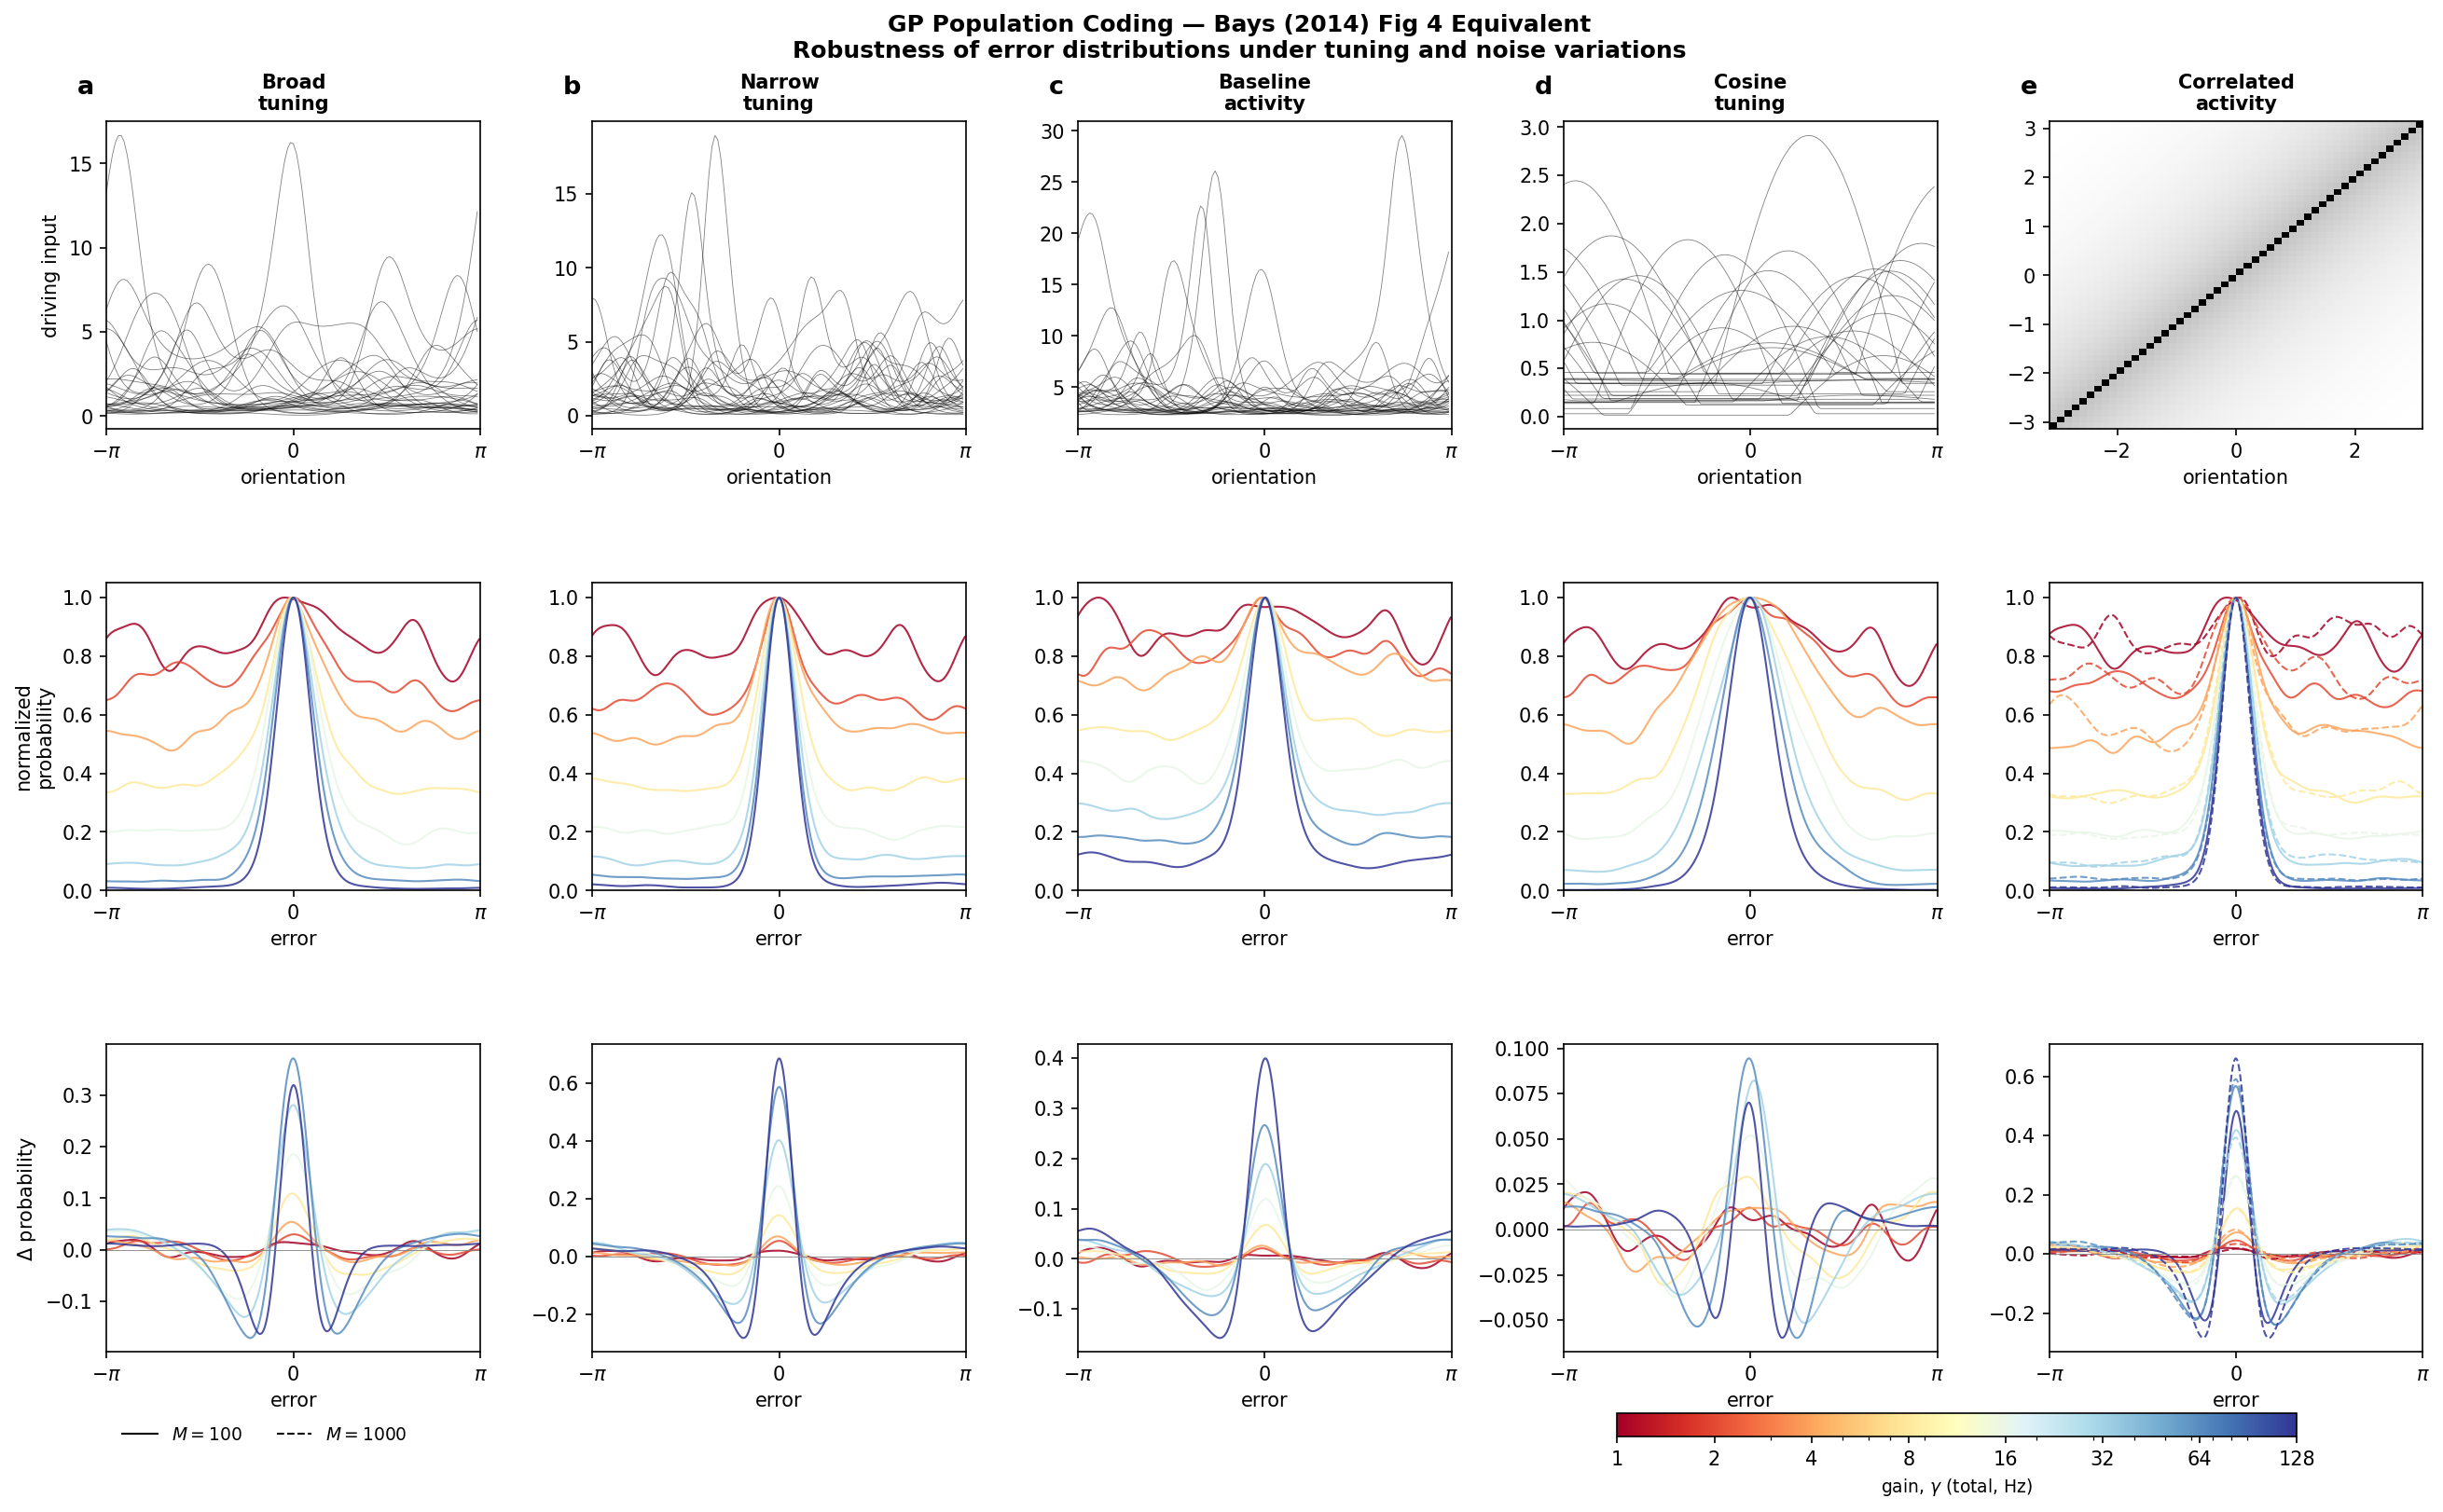

In [10]:
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(3, 5, hspace=0.50, wspace=0.30,
                        left=0.05, right=0.97, bottom=0.08, top=0.88)

# Bays-style colormap: low gain = red, high gain = blue
gain_cmap = plt.cm.RdYlBu
gain_norm = mcolors.LogNorm(vmin=min(GAMMAS_TOTAL), vmax=max(GAMMAS_TOTAL))

panel_ids = ['a', 'b', 'c', 'd', 'e']
titles    = ['Broad\ntuning', 'Narrow\ntuning', 'Baseline\nactivity',
             'Cosine\ntuning', 'Correlated\nactivity']

for col, pid in enumerate(panel_ids):
    p = panels[pid]
    thetas = p['thetas']
    pop_sizes = p['pop_sizes']
    M_ref = pop_sizes[0]

    # ---------- Row 1: tuning curves OR correlation matrix ----------
    ax_top = fig.add_subplot(gs[0, col])
    if pid == 'e':
        C = p[f'corr_matrix_{M_ref}']
        n_show = min(50, C.shape[0])
        ax_top.imshow(C[:n_show, :n_show], cmap='gray_r', origin='lower',
                      aspect='auto', extent=[-np.pi, np.pi, -np.pi, np.pi])
        ax_top.set_xlabel('orientation')
        if col == 0:
            ax_top.set_ylabel('orientation')
    else:
        g_ex = p.get(f'g_example_{M_ref}', p['g'][:30])
        for i in range(min(30, g_ex.shape[0])):
            ax_top.plot(thetas, g_ex[i], 'k-', lw=0.4, alpha=0.5)
        ax_top.set_xlabel('orientation')
        if col == 0:
            ax_top.set_ylabel('driving input')
        ax_top.set_xlim(-np.pi, np.pi)
        ax_top.set_xticks([-np.pi, 0, np.pi])
        ax_top.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])

    ax_top.set_title(titles[col], fontsize=10, fontweight='bold')
    ax_top.text(-0.08, 1.15, f'$\\mathbf{{{pid}}}$',
                transform=ax_top.transAxes, fontsize=13,
                fontweight='bold', va='top')

    # ---------- Row 2: normalised error distributions ----------
    ax_mid = fig.add_subplot(gs[1, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        for gt in GAMMAS_TOTAL:
            key = (gt, M)
            if key not in p['results']:
                continue
            dev  = p['results'][key]
            emp  = dev['empirical']
            peak = emp.max()
            if peak > 0:
                ax_mid.plot(dev['centers'], emp / peak,
                            color=gain_cmap(gain_norm(gt)),
                            lw=1.0, ls=ls, alpha=0.85)
    ax_mid.set_xlim(-np.pi, np.pi)
    ax_mid.set_ylim(0, 1.05)
    ax_mid.set_xticks([-np.pi, 0, np.pi])
    ax_mid.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_mid.set_xlabel('error')
    if col == 0:
        ax_mid.set_ylabel('normalized\nprobability')

    # ---------- Row 3: deviation from circular normal ----------
    ax_bot = fig.add_subplot(gs[2, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        for gt in GAMMAS_TOTAL:
            key = (gt, M)
            if key not in p['results']:
                continue
            dev = p['results'][key]
            ax_bot.plot(dev['centers'], dev['deviation'],
                        color=gain_cmap(gain_norm(gt)),
                        lw=1.0, ls=ls, alpha=0.85)
    ax_bot.axhline(0, color='gray', lw=0.4)
    ax_bot.set_xlim(-np.pi, np.pi)
    ax_bot.set_xticks([-np.pi, 0, np.pi])
    ax_bot.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_bot.set_xlabel('error')
    if col == 0:
        ax_bot.set_ylabel(r'$\Delta$ probability')

# ---------- Legend & colorbar ----------
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='k', lw=1, ls='-',  label=r'$M=100$'),
           Line2D([0], [0], color='k', lw=1, ls='--', label=r'$M=1000$')]
fig.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.05, 0.01),
           fontsize=9, frameon=False, ncol=2)

sm = plt.cm.ScalarMappable(cmap=gain_cmap, norm=gain_norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.65, 0.025, 0.27, 0.015])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label(r'gain, $\gamma$ (total, Hz)', fontsize=9)
cb.set_ticks(GAMMAS_TOTAL)
cb.set_ticklabels([str(g) for g in GAMMAS_TOTAL])

fig.suptitle('GP Population Coding — Bays (2014) Fig 4 Equivalent\n'
             'Robustness of error distributions under tuning and noise variations',
             fontsize=12, fontweight='bold', y=0.95)

plt.savefig('bays_fig4_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

### Sanity check: kurtosis vs gain

The Bays signature is **non-monotonic** kurtosis with respect to gain:

- highest gains → CLT → errors approximately von Mises → kurtosis ≈ 0
- lowest gains  → errors approximately uniform → kurtosis ≈ 0
- **intermediate** gains → sharp peak + heavy tails → kurtosis > 0 (peak)

If the previous figure was producing artefacts (delta-spike at zero error from
decoder grid quantisation), the kurtosis trace would have been monotonic in gain.
With the high-resolution decoder it should now be a clear inverted-U.


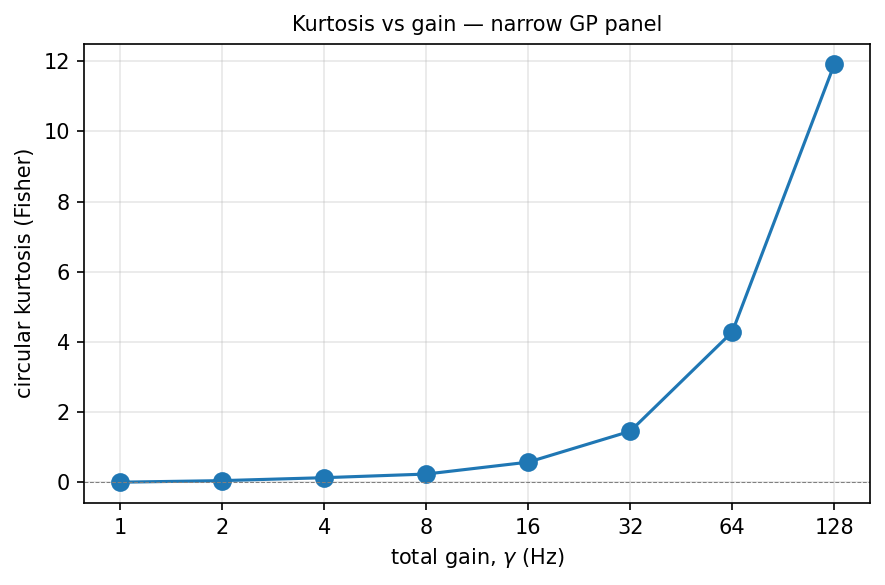


Kurtosis trace (γ_total, kurtosis):
  γ =   1  →  κ = +0.005
  γ =   2  →  κ = +0.050
  γ =   4  →  κ = +0.134
  γ =   8  →  κ = +0.237
  γ =  16  →  κ = +0.576
  γ =  32  →  κ = +1.457
  γ =  64  →  κ = +4.286
  γ = 128  →  κ = +11.910


In [11]:
def circular_kurtosis_fisher(errors):
    """Fisher (1995) circular kurtosis — same definition as core/decoder/ml_decoder."""
    m1   = np.mean(np.exp(1j * errors))
    m2   = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V    = 1.0 - rho1
    if V <= 1e-10:
        return 0.0
    phase_corr = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_corr - rho1**4) / V**2


# Re-run a single panel (narrow GP) at all gains and collect kurtosis.
thetas_chk, g_chk = make_gp_population_shared_kernel(
    M_DEFAULT, N_THETA, LAMBDA_NARROW, SEED + ord('b'))

kurt_trace = []
for gt in GAMMAS_TOTAL:
    rng = np.random.RandomState(SEED + 999 + gt)
    errs = run_trials(g_chk, thetas_chk, gt / M_DEFAULT, T_D, SIGMA_SQ,
                      N_TRIALS, rng, n_decode=N_DECODE)
    kurt_trace.append(circular_kurtosis_fisher(errs))

fig2, ax = plt.subplots(figsize=(6, 4))
ax.plot(GAMMAS_TOTAL, kurt_trace, 'o-', color='C0', lw=1.5, markersize=8)
ax.set_xscale('log', base=2)
ax.set_xticks(GAMMAS_TOTAL)
ax.set_xticklabels([str(g) for g in GAMMAS_TOTAL])
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel(r'total gain, $\gamma$ (Hz)')
ax.set_ylabel('circular kurtosis (Fisher)')
ax.set_title('Kurtosis vs gain — narrow GP panel', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bays_fig4_kurtosis_check.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKurtosis trace (γ_total, kurtosis):")
for gt, k in zip(GAMMAS_TOTAL, kurt_trace):
    print(f"  γ = {gt:>3d}  →  κ = {k:+.3f}")

---

# Bays (2014) Figure 5 — Identifiability of baseline-extended GP model

Bays's basic model (Eq. 1) gives every neuron a tuning function that drops to **zero**
at the worst orientation. Real cortical neurons fire at some nonzero spontaneous rate
even when stimulated by their least preferred orientation. The baseline extension
(Bays Eq. 14) adds a constant floor $f_{(0)}$ to the tuning curve, parameterised as a
fraction of peak: $f_{(0)}/(f_{(0)}+1)$.

### Why this figure exists

When Bays fits his basic (no-baseline) model to behavioural data he recovers $\gamma$
in the range of ~100 Hz. That is implausibly low — real cortical neurons fire much
faster during sustained working memory. The natural critique is: *"your model only
works because you've fitted a non-physiological firing rate."*

Figure 5 is Bays's defence. The argument has three parts.

1. **Identifiability fails along (γ, $f_{(0)}$).** As baseline rises, the ML γ that
   reproduces the data rises *with* it — by orders of magnitude. The data cannot tell
   "low γ, no baseline" apart from "high γ, lots of baseline."

2. **The error distributions are invariant** across this (γ, $f_{(0)}$) family. Panel c
   in Bays shows recall distributions at multiple baseline levels that overlap almost
   exactly — the model's *behavioural predictions* are unaffected by the unidentifiable
   trade-off.

3. **What is invariant under the hood is SNR per neuron.** Mean rate goes up with γ,
   variance of rate across orientations also goes up with γ, but the ratio — which is
   what determines decoding precision under Poisson noise — stays approximately constant.

The punchline: the basic model's "implausibly low" γ is not a literal prediction. The
model is *equally consistent* with realistic firing rates accompanied by substantial
baseline. What the model actually pins down is SNR, and the SNR values are physiologically
reasonable.

### What we test here

The same argument should generalise to the GP framework. We refit (γ, ω) jointly at
each baseline level by full ML against the zero-baseline reference error distribution.
If the GP model exhibits Bays-style identifiability, we expect:

| Panel | Quantity                       | Expected GP behaviour                              |
|-------|--------------------------------|----------------------------------------------------|
| **a** | ML γ vs baseline (log scale)   | Steep rise — γ absorbs the baseline trade-off      |
| **b** | ML ω vs baseline               | Mild drift — tuning width is more identifiable     |
| **c** | Error distributions overlaid   | Approximately invariant across baseline levels     |
| **d** | SNR per neuron vs baseline     | Approximately flat — the conserved quantity        |

If panels c or d show large deviations, the GP framework departs from Bays's
identifiability in an interesting way.


### Method

**Reference data.** Generate a large pool of single-item errors at $(\gamma_{\text{ref}}, \omega_{\text{ref}}, f_0 = 0)$.
This is the "subject data" we're fitting to — analogous to Bays fitting his model to
human errors. Reference params match Bays's group means: $\omega = 0.52$, $\gamma_{\text{total}} = 119$ Hz.

**Likelihood.** For each candidate $(\gamma, \omega)$ at each baseline $b$, simulate $N_{\text{sim}}$
single-item errors, build a 50-bin histogram on $[-\pi, \pi)$ (Bays's bin count),
floor the empty bins to avoid $\log 0$, and compute
$\log \mathcal{L}(\gamma, \omega; b) = \sum_t \log \hat{p}(\varepsilon_t^{\text{ref}})$.

**Search.** Coarse-to-fine 2D grid: 16 × 8 log-spaced grid over a wide range, then a
refined 5 × 5 grid centred on the coarse optimum. Coarse sims use $N_{\text{sim}} = 3000$;
refined sims use $N_{\text{sim}} = 5000$. This keeps total runtime under ~10 min for
the full sweep.

**SNR formula.** GP analog of Bays Eq. 15:
$$\mathrm{SNR} = T_d \cdot \frac{\mathrm{Var}_\theta[r(\theta)]}{\mathbb{E}_\theta[r(\theta)]}$$
averaged over neurons, evaluated at ML $(\gamma, \omega)$.

**One GP-specific subtlety.** Each $(\omega, b)$ generates a *new* GP population draw — the
underlying tuning curves are different random functions, not re-tuned versions of the
same neurons. We hold the GP seed fixed across the grid (so changing $\omega$ rescales
the same latent vectors through a different kernel) to minimise this confound, but it
is a structural difference from Bays whose tuning curves are deterministic given $\omega$.


In [ ]:
# =====================================================================
# Figure 5 helpers — histogram likelihood, SNR, joint ML
# =====================================================================

def errors_to_hist(errors, n_bins=50, eps_floor=None):
    """
    Bin signed circular errors on [−π, π) into a normalised density estimate.

    Returns (centers, density, bin_width). Empty bins are floored to avoid
    log(0) when computing histogram likelihoods of reference data.
    """
    edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bw = edges[1] - edges[0]
    counts, _ = np.histogram(errors, bins=edges)
    density = counts / (errors.size * bw)            # normalises to ∫=1
    if eps_floor is None:
        eps_floor = 1.0 / (errors.size * bw * 10)    # ≈ 1/10 of a single-count bin
    density = np.maximum(density, eps_floor)
    return centers, density, bw, edges


def loglik_of_ref(ref_errors, sim_errors, n_bins=50):
    """
    Log-likelihood of `ref_errors` under the empirical density of `sim_errors`.

    Build a histogram from `sim_errors` (the model's predicted distribution at
    candidate params), then sum log p̂(ε) over each reference observation.
    """
    centers, density, bw, edges = errors_to_hist(sim_errors, n_bins=n_bins)
    # Bin each ref error
    bin_idx = np.clip(np.searchsorted(edges, ref_errors, side='right') - 1,
                      0, n_bins - 1)
    return float(np.sum(np.log(density[bin_idx])))


def snr_per_neuron_gp(g, gamma_per_neuron, T_d, sigma_sq):
    """
    GP analog of Bays Eq. 15.

    Per-neuron SNR = T_d · Var_θ[r(θ)] / E_θ[r(θ)], averaged over neurons.
    Uses post-DN rates at the supplied γ.
    """
    M, n_theta = g.shape
    mean_g = np.mean(g, axis=0)                                  # (n_theta,)
    rates = gamma_per_neuron * g / (sigma_sq + mean_g)[None, :]   # (M, n_theta)
    E_r  = np.mean(rates, axis=1)                                # (M,)
    Var_r = np.mean(rates**2, axis=1) - E_r**2
    snr = T_d * Var_r / np.maximum(E_r, 1e-15)                   # (M,)
    return float(np.mean(snr))


def joint_ml_fit(ref_errors, lambda_grid, gamma_total_grid, baseline_frac,
                 M, n_theta, T_d, sigma_sq, n_sim, seed, n_bins=50,
                 verbose=False):
    """
    Joint (γ, ω) ML over a 2D grid at fixed baseline.

    Returns the full log-likelihood surface and the argmax indices.

    ω is parameterised through λ; ω = λ². γ_total is total post-DN gain
    (per-neuron γ inside run_trials is γ_total / M).
    """
    n_lam = len(lambda_grid)
    n_gam = len(gamma_total_grid)
    ll_surface = np.full((n_lam, n_gam), -np.inf)

    for il, lam in enumerate(lambda_grid):
        thetas_l, g_l = make_gp_with_baseline(M, n_theta, lam, baseline_frac, seed)
        for ig, gt in enumerate(gamma_total_grid):
            rng = np.random.RandomState(seed + 1000 + il * n_gam + ig)
            sim_errs = run_trials(
                g_l, thetas_l, gt / M, T_d, sigma_sq, n_sim, rng,
                n_decode=N_DECODE)
            ll_surface[il, ig] = loglik_of_ref(ref_errors, sim_errs, n_bins=n_bins)
        if verbose:
            i_best = np.argmax(ll_surface[il])
            print(f'    λ={lam:.3f} (ω={lam**2:.3f}): best γ={gamma_total_grid[i_best]:.1f} Hz, '
                  f'll={ll_surface[il, i_best]:.1f}')

    il_star, ig_star = np.unravel_index(np.argmax(ll_surface), ll_surface.shape)
    return ll_surface, (il_star, ig_star)


In [ ]:
# =====================================================================
# Figure 5 configuration
# =====================================================================

# Reference parameters (Bays group means from his Fig 2b)
OMEGA_REF_F5     = 0.52
LAMBDA_REF_F5    = np.sqrt(OMEGA_REF_F5)       # ω = λ²
GAMMA_REF_TOTAL  = 119.0                       # Hz (total post-DN)

# Baseline fractions to sweep (matches the spread in Bays Fig 5)
BASELINE_FRACS_F5 = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.80, 0.90]

# Joint-ML grid (coarse)
GAMMA_GRID_COARSE  = np.logspace(np.log10(50), np.log10(2e5), 16)
LAMBDA_GRID_COARSE = np.sqrt(np.logspace(np.log10(0.12), np.log10(2.0), 8))
# Refined: ±2 grid steps around coarse optimum, 5×5

# Trial budgets
N_REF_TRIALS_F5    = 10000     # size of the reference 'subject' dataset
N_SIM_COARSE       = 3000
N_SIM_REFINED      = 5000
N_SIM_FINAL        = 5000      # for the panel-c distributions

# Histogram bin count for likelihood
N_BINS_F5          = 50

SEED_F5 = SEED + 7000

print(f'Reference: ω = {OMEGA_REF_F5}, γ_total = {GAMMA_REF_TOTAL} Hz, baseline = 0')
print(f'Baseline grid: {len(BASELINE_FRACS_F5)} levels from 0 to {BASELINE_FRACS_F5[-1]:.0%}')
print(f'Coarse grid: {len(LAMBDA_GRID_COARSE)} λ × {len(GAMMA_GRID_COARSE)} γ '
      f'= {len(LAMBDA_GRID_COARSE) * len(GAMMA_GRID_COARSE)} points per baseline')
print(f'  λ range: {LAMBDA_GRID_COARSE.min():.3f} – {LAMBDA_GRID_COARSE.max():.3f} '
      f'(ω: {LAMBDA_GRID_COARSE.min()**2:.3f} – {LAMBDA_GRID_COARSE.max()**2:.3f})')
print(f'  γ range: {GAMMA_GRID_COARSE.min():.1f} – {GAMMA_GRID_COARSE.max():.0f} Hz')


### Run: joint (γ, ω) ML at each baseline

For each baseline level: (1) coarse grid → (2) refined local grid → (3) record ML
parameters, SNR at those parameters, and a final 5k-trial error distribution for
the panel-c overlay.


In [ ]:
# =====================================================================
# Step 1: build reference 'subject' dataset at (γ_ref, ω_ref, baseline=0)
# =====================================================================
t0 = time.time()

thetas_ref, g_ref = make_gp_with_baseline(
    M_DEFAULT, N_THETA, LAMBDA_REF_F5, 0.0, SEED_F5)
rng_ref = np.random.RandomState(SEED_F5 + 1)
ref_errors = run_trials(
    g_ref, thetas_ref, GAMMA_REF_TOTAL / M_DEFAULT,
    T_D, SIGMA_SQ, N_REF_TRIALS_F5, rng_ref, n_decode=N_DECODE)

ref_rho1 = float(np.abs(np.mean(np.exp(1j * ref_errors))))
print(f'Reference: {N_REF_TRIALS_F5} trials, '
      f'σ² = {-2*np.log(max(ref_rho1, 1e-15)):.4f}')

# =====================================================================
# Step 2: joint ML at each baseline level (coarse → refined)
# =====================================================================
fig5_results = {}

for bf in BASELINE_FRACS_F5:
    tb = time.time()
    print(f'\nBaseline = {bf*100:.0f}%')

    # --- coarse grid ---
    print('  Coarse grid...')
    ll_coarse, (il_c, ig_c) = joint_ml_fit(
        ref_errors, LAMBDA_GRID_COARSE, GAMMA_GRID_COARSE, bf,
        M_DEFAULT, N_THETA, T_D, SIGMA_SQ, N_SIM_COARSE,
        seed=SEED_F5 + int(bf * 100), n_bins=N_BINS_F5)
    lam_c  = LAMBDA_GRID_COARSE[il_c]
    gt_c   = GAMMA_GRID_COARSE[ig_c]
    print(f'    coarse optimum: λ={lam_c:.3f} (ω={lam_c**2:.3f}), '
          f'γ={gt_c:.1f} Hz, ll={ll_coarse[il_c, ig_c]:.1f}')

    # --- refined local grid (5×5 around the coarse optimum) ---
    # ±1 coarse-grid step in each direction. If the coarse optimum is at a
    # boundary we widen the refinement to the next-nearest interior step so
    # we don't collapse to a degenerate single-point range.
    n_lam_c, n_gam_c = len(LAMBDA_GRID_COARSE), len(GAMMA_GRID_COARSE)
    if il_c == 0:
        il_lo, il_hi = 0, min(n_lam_c - 1, 2)
    elif il_c == n_lam_c - 1:
        il_lo, il_hi = max(0, n_lam_c - 3), n_lam_c - 1
    else:
        il_lo, il_hi = il_c - 1, il_c + 1
    if ig_c == 0:
        ig_lo, ig_hi = 0, min(n_gam_c - 1, 2)
    elif ig_c == n_gam_c - 1:
        ig_lo, ig_hi = max(0, n_gam_c - 3), n_gam_c - 1
    else:
        ig_lo, ig_hi = ig_c - 1, ig_c + 1
    LAM_REFINED = np.linspace(LAMBDA_GRID_COARSE[il_lo], LAMBDA_GRID_COARSE[il_hi], 5)
    GAM_REFINED = np.logspace(np.log10(GAMMA_GRID_COARSE[ig_lo]),
                              np.log10(GAMMA_GRID_COARSE[ig_hi]), 5)

    print('  Refined grid...')
    ll_fine, (il_f, ig_f) = joint_ml_fit(
        ref_errors, LAM_REFINED, GAM_REFINED, bf,
        M_DEFAULT, N_THETA, T_D, SIGMA_SQ, N_SIM_REFINED,
        seed=SEED_F5 + int(bf * 100) + 11, n_bins=N_BINS_F5)

    lam_ml = LAM_REFINED[il_f]
    gt_ml  = GAM_REFINED[ig_f]
    om_ml  = lam_ml ** 2
    # Edge-of-grid warning: tells us the true ML is outside what we searched.
    if il_f in (0, len(LAM_REFINED) - 1):
        print(f'    [warn] ML λ at refinement edge ({lam_ml:.3f}) '
              f'— widen LAMBDA_GRID_COARSE if this persists')
    if ig_f in (0, len(GAM_REFINED) - 1):
        print(f'    [warn] ML γ at refinement edge ({gt_ml:.1f} Hz) '
              f'— widen GAMMA_GRID_COARSE if this persists')

    # --- final simulation at ML params for panel-c ---
    thetas_ml, g_ml = make_gp_with_baseline(
        M_DEFAULT, N_THETA, lam_ml, bf, SEED_F5 + int(bf * 100) + 22)
    rng_final = np.random.RandomState(SEED_F5 + int(bf * 100) + 33)
    final_errors = run_trials(
        g_ml, thetas_ml, gt_ml / M_DEFAULT, T_D, SIGMA_SQ,
        N_SIM_FINAL, rng_final, n_decode=N_DECODE)

    snr = snr_per_neuron_gp(g_ml, gt_ml / M_DEFAULT, T_D, SIGMA_SQ)

    fig5_results[bf] = {
        'lambda':       lam_ml,
        'omega':        om_ml,
        'gamma_total':  gt_ml,
        'snr':          snr,
        'errors':       final_errors,
        'll_coarse':    ll_coarse,
        'lam_coarse':   LAMBDA_GRID_COARSE,
        'gam_coarse':   GAMMA_GRID_COARSE,
        'll_refined':   ll_fine,
        'lam_refined':  LAM_REFINED,
        'gam_refined':  GAM_REFINED,
    }
    print(f'    ML: ω={om_ml:.3f}, γ_total={gt_ml:.1f} Hz, SNR={snr:.4f} '
          f'({time.time()-tb:.1f}s)')

print(f'\nFigure 5 sweep done in {time.time()-t0:.1f}s')


### Figure 5 plot — 2 × 2

- **Panel a**: ML γ_total vs baseline (log scale). Should rise steeply.
- **Panel b**: ML ω vs baseline. Should drift only mildly — *if* the GP framework
  inherits Bays's identifiability.
- **Panel c**: Error distributions at each baseline, overlaid. Should be approximately
  invariant if the joint ML is doing its job.
- **Panel d**: SNR per neuron vs baseline. Should be approximately flat — the
  conserved quantity.


In [ ]:
# =====================================================================
# Figure 5 plot
# =====================================================================
fig5 = plt.figure(figsize=(13, 10))
gs5 = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.30,
                        left=0.08, right=0.96, bottom=0.06, top=0.92)

x_pct = [bf * 100 for bf in BASELINE_FRACS_F5]
GREY = '#444444'
baseline_cmap = plt.cm.viridis
baseline_norm = mcolors.Normalize(vmin=0, vmax=max(x_pct))

# === Panel a: γ vs baseline (log y) ===
ax_a = fig5.add_subplot(gs5[0, 0])
gammas = [fig5_results[bf]['gamma_total'] for bf in BASELINE_FRACS_F5]
ax_a.semilogy(x_pct, gammas, 'o-', color=GREY, lw=1.5, ms=6)
ax_a.set_xlabel('baseline (% of peak)')
ax_a.set_ylabel(r'ML gain, $\gamma_{\mathrm{total}}$ (Hz)')
ax_a.text(-0.15, 1.06, r'$\mathbf{a}$', transform=ax_a.transAxes,
          fontsize=16, fontweight='bold', va='top')
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.grid(alpha=0.2)

# === Panel b: ω vs baseline ===
ax_b = fig5.add_subplot(gs5[0, 1])
omegas = [fig5_results[bf]['omega'] for bf in BASELINE_FRACS_F5]
ax_b.plot(x_pct, omegas, 'o-', color=GREY, lw=1.5, ms=6)
ax_b.axhline(OMEGA_REF_F5, color='C3', lw=0.8, ls='--', alpha=0.6,
             label=f'reference ω = {OMEGA_REF_F5}')
ax_b.set_xlabel('baseline (% of peak)')
ax_b.set_ylabel(r'ML width, $\omega\;(= \lambda^2)$')
ax_b.set_yscale('log', base=2)
om_min, om_max = min(omegas + [OMEGA_REF_F5]) * 0.6, max(omegas + [OMEGA_REF_F5]) * 1.6
ax_b.set_ylim(om_min, om_max)
ax_b.legend(fontsize=8, frameon=False, loc='best')
ax_b.text(-0.15, 1.06, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=16, fontweight='bold', va='top')
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.grid(alpha=0.2)

# === Panel c: error distributions overlaid ===
ax_c = fig5.add_subplot(gs5[1, 0])
n_eval_c = 400
theta_smooth = np.linspace(-np.pi, np.pi, n_eval_c, endpoint=False)
for bf in BASELINE_FRACS_F5:
    errs = fig5_results[bf]['errors']
    # Use the same vM KDE used in Figure 4 for visual consistency
    pdf = vm_kde(errs, theta_smooth, kappa_kde=25.0)
    color = baseline_cmap(baseline_norm(bf * 100))
    ax_c.plot(theta_smooth, pdf, color=color, lw=1.3,
              label=f'{bf*100:.0f}%')
ax_c.set_xlim(-np.pi, np.pi)
ax_c.set_xticks([-np.pi, 0, np.pi])
ax_c.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
ax_c.set_xlabel('error'); ax_c.set_ylabel('probability density')
ax_c.legend(fontsize=7, title='baseline', loc='upper right', ncol=2,
            frameon=False, title_fontsize=8)
ax_c.text(-0.15, 1.06, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=16, fontweight='bold', va='top')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# === Panel d: SNR vs baseline ===
ax_d = fig5.add_subplot(gs5[1, 1])
snrs = [fig5_results[bf]['snr'] for bf in BASELINE_FRACS_F5]
ax_d.plot(x_pct, snrs, 'o-', color=GREY, lw=1.5, ms=6)
ax_d.set_xlabel('baseline (% of peak)')
ax_d.set_ylabel('SNR per neuron')
ax_d.text(-0.15, 1.06, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=16, fontweight='bold', va='top')
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)
ax_d.grid(alpha=0.2)
# Annotate fractional variation
snr_arr = np.array(snrs)
snr_cv = np.std(snr_arr) / np.mean(snr_arr)
ax_d.text(0.97, 0.03, f'CV(SNR) = {snr_cv:.3f}',
          transform=ax_d.transAxes, fontsize=8, ha='right', va='bottom',
          color='#666666')

fig5.suptitle('GP Population Coding — Bays (2014) Fig 5 Equivalent\n'
              'Identifiability of (γ, ω) under baseline activity; SNR as invariant',
              fontsize=12, fontweight='bold')
plt.savefig('bays_fig5_equivalent.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\nSummary of joint ML fits:')
print(f'{"baseline":>10s}  {"γ_total":>10s}  {"ω":>8s}  {"SNR":>10s}')
for bf in BASELINE_FRACS_F5:
    r = fig5_results[bf]
    print(f'{bf*100:>9.0f}%  {r["gamma_total"]:>10.1f}  {r["omega"]:>8.3f}  {r["snr"]:>10.4f}')
